# Real Pendulum Omega Calibration

This notebook checks whether the hardware velocity signal `omega` has a sign, scale, bias, or delay error. It compares the setup-provided `omega` against a velocity estimate computed from the measured angle.

Use small voltage tests first. Keep a hand near the emergency stop / disconnect path.

## 1. Setup

In [35]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Make the local package importable when this notebook is opened from nearby folders.
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / 'gym_unbalanced_disk').exists():
        sys.path.insert(0, str(parent))
        break

import gym_unbalanced_disk

DT = 0.025
UMAX = 3.0
RUN_STEPS = 800
SEED = 46

# Start gently. Increase TEST_AMPLITUDE only if the motion is too small to estimate velocity.
TEST_AMPLITUDE = 1.0
INPUT_MODE = 'filtered_noise'  # 'filtered_noise', 'sine', or 'manual_zero'
SINE_FREQ_HZ = 0.35

SAVE_DATA = True
OUTPUT_DIR = Path('omega_calibration_logs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'DT={DT}, RUN_STEPS={RUN_STEPS}, duration={RUN_STEPS * DT:.1f}s, TEST_AMPLITUDE={TEST_AMPLITUDE} V')

DT=0.025, RUN_STEPS=800, duration=20.0s, TEST_AMPLITUDE=1.0 V


## 2a. Optional Stationary Offset Check

Run this before the driven calibration if you want to verify that the omega bias is real. Keep the pendulum physically still, use zero motor voltage, and repeat a few short trials. If the raw omega mean is consistently away from zero, that is direct evidence of a sensor offset.


USB read error
USB read error
USB read error
trial 01: mean raw omega=-4.6324 rad/s, offset-only=+4.6324, std=0.8506, theta drift=+0.0000 rad
trial 02: mean raw omega=-4.5745 rad/s, offset-only=+4.5745, std=0.7836, theta drift=+0.0000 rad
USB read error
trial 03: mean raw omega=-4.7005 rad/s, offset-only=+4.7005, std=0.7704, theta drift=+0.0000 rad
trial 04: mean raw omega=-4.5275 rad/s, offset-only=+4.5275, std=0.8137, theta drift=+0.0000 rad
trial 05: mean raw omega=-4.6010 rad/s, offset-only=+4.6010, std=0.7197, theta drift=+0.0000 rad
trial 06: mean raw omega=-4.6134 rad/s, offset-only=+4.6134, std=0.7922, theta drift=+0.0000 rad

Stationary offset summary
  recommended offset-only correction: omega_corrected = omega_raw + +4.607183
  robust trial-to-trial spread:       0.042944 rad/s
  mean within-trial raw omega std:    0.788362 rad/s


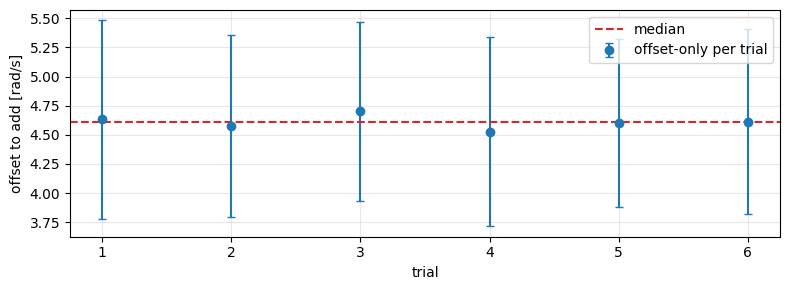

In [38]:
# Set True in the lab when the pendulum is physically still.
RUN_STATIONARY_OFFSET_TEST = True

STATIONARY_TRIALS = 6
STATIONARY_SECONDS = 6.0
STATIONARY_STEPS = int(STATIONARY_SECONDS / DT)
STATIONARY_SETTLE_STEPS = 10

stationary_offsets = []
stationary_means = []
stationary_stds = []
stationary_theta_drifts = []

if RUN_STATIONARY_OFFSET_TEST:
    env = gym_unbalanced_disk.UnbalancedDisk_exp(dt=DT, umax=UMAX)
    try:
        for trial in range(STATIONARY_TRIALS):
            obs, info = env.reset()
            for _ in range(STATIONARY_SETTLE_STEPS):
                obs, *_ = env.step(0.0)

            theta_trial = []
            omega_trial = []
            for _ in range(STATIONARY_STEPS):
                theta_trial.append(float(obs[0]))
                omega_trial.append(float(obs[1]))
                obs, *_ = env.step(0.0)

            theta_trial = np.asarray(theta_trial)
            omega_trial = np.asarray(omega_trial)
            raw_mean = float(np.mean(omega_trial))
            raw_std = float(np.std(omega_trial))
            theta_drift = float(theta_trial[-1] - theta_trial[0]) if len(theta_trial) else np.nan
            offset_only = -raw_mean

            stationary_means.append(raw_mean)
            stationary_stds.append(raw_std)
            stationary_theta_drifts.append(theta_drift)
            stationary_offsets.append(offset_only)

            print(
                f'trial {trial + 1:02d}: mean raw omega={raw_mean:+.4f} rad/s, '
                f'offset-only={offset_only:+.4f}, std={raw_std:.4f}, '
                f'theta drift={theta_drift:+.4f} rad'
            )
    finally:
        try:
            env.step(0.0)
        finally:
            env.close()

    stationary_offsets = np.asarray(stationary_offsets)
    stationary_means = np.asarray(stationary_means)
    stationary_stds = np.asarray(stationary_stds)
    stationary_theta_drifts = np.asarray(stationary_theta_drifts)

    STATIONARY_OFFSET_ONLY = float(np.median(stationary_offsets))
    STATIONARY_OFFSET_SPREAD = float(
        1.4826 * np.median(np.abs(stationary_offsets - STATIONARY_OFFSET_ONLY))
    )

    print('\nStationary offset summary')
    print(
        f'  recommended offset-only correction: '
        f'omega_corrected = omega_raw + {STATIONARY_OFFSET_ONLY:+.6f}'
    )
    print(f'  robust trial-to-trial spread:       {STATIONARY_OFFSET_SPREAD:.6f} rad/s')
    print(f'  mean within-trial raw omega std:    {float(np.mean(stationary_stds)):.6f} rad/s')

    plt.figure(figsize=(8, 3))
    plt.errorbar(
        np.arange(1, len(stationary_offsets) + 1),
        stationary_offsets,
        yerr=stationary_stds,
        fmt='o',
        capsize=3,
        label='offset-only per trial',
    )
    plt.axhline(STATIONARY_OFFSET_ONLY, color='tab:red', ls='--', label='median')
    plt.xlabel('trial')
    plt.ylabel('offset to add [rad/s]')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Stationary offset test skipped. Set RUN_STATIONARY_OFFSET_TEST = True in the lab to run it.')


## 2. Build a Safe Test Input

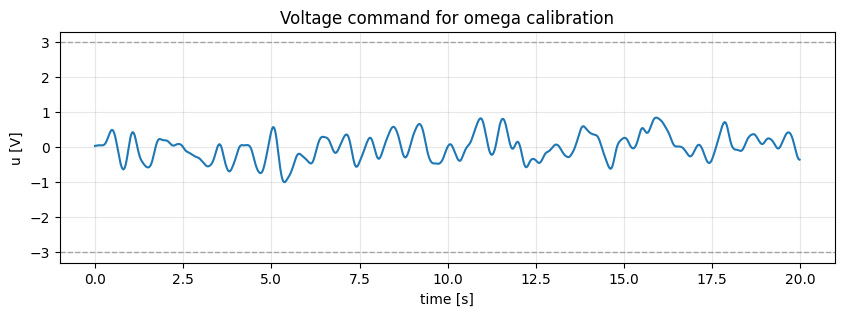

In [39]:
rng = np.random.default_rng(SEED)
t_cmd = np.arange(RUN_STEPS) * DT

if INPUT_MODE == 'filtered_noise':
    raw = rng.uniform(-1.0, 1.0, size=RUN_STEPS)
    b, a = signal.butter(4, 0.08)
    ulist = signal.lfilter(b, a, raw)
    ulist -= np.mean(ulist)
    ulist /= max(np.max(np.abs(ulist)), 1e-9)
    ulist = TEST_AMPLITUDE * ulist
elif INPUT_MODE == 'sine':
    ulist = TEST_AMPLITUDE * np.sin(2 * np.pi * SINE_FREQ_HZ * t_cmd)
elif INPUT_MODE == 'manual_zero':
    ulist = np.zeros(RUN_STEPS)
else:
    raise ValueError(f'Unknown INPUT_MODE: {INPUT_MODE}')

ulist = np.clip(ulist, -UMAX, UMAX)

plt.figure(figsize=(10, 3))
plt.plot(t_cmd, ulist)
plt.axhline(UMAX, color='k', ls='--', lw=1, alpha=0.3)
plt.axhline(-UMAX, color='k', ls='--', lw=1, alpha=0.3)
plt.title('Voltage command for omega calibration')
plt.xlabel('time [s]')
plt.ylabel('u [V]')
plt.grid(alpha=0.3)
plt.show()

## 3. Collect Hardware Data

This cell connects to the real setup, applies `ulist`, logs raw angle and reported omega, then sends zero voltage and closes the USB connection.

In [40]:
env = gym_unbalanced_disk.UnbalancedDisk_exp(dt=DT, umax=UMAX)

theta_list = []
omega_reported_list = []
u_applied_list = []
wall_time_list = []

try:
    obs, info = env.reset()
    t0 = time.perf_counter()
    for k, u in enumerate(ulist):
        theta_list.append(float(obs[0]))
        omega_reported_list.append(float(obs[1]))
        u_applied_list.append(float(u))
        wall_time_list.append(time.perf_counter() - t0)

        obs, reward, terminal, truncated, info = env.step(float(u))
        if k < 10:
            print(f'k={k:03d} theta={theta_list[-1]:+.3f} omega_reported={omega_reported_list[-1]:+.3f} u={u:+.3f}')
finally:
    try:
        env.step(0.0)
    finally:
        env.close()

theta = np.asarray(theta_list)
omega_reported = np.asarray(omega_reported_list)
u_applied = np.asarray(u_applied_list)
wall_time = np.asarray(wall_time_list)
t = np.arange(len(theta)) * DT

print(f'Collected {len(theta)} samples ({len(theta) * DT:.1f}s)')
print(f'theta range: {theta.min():+.3f} to {theta.max():+.3f} rad')
print(f'reported omega range: {omega_reported.min():+.3f} to {omega_reported.max():+.3f} rad/s')

if SAVE_DATA:
    stamp = time.strftime('%Y%m%d_%H%M%S')
    data_path = OUTPUT_DIR / f'omega_calibration_{stamp}.npz'
    np.savez(
        data_path,
        t=t,
        wall_time=wall_time,
        theta=theta,
        omega_reported=omega_reported,
        u_applied=u_applied,
        dt=DT,
    )
    print(f'Saved raw data: {data_path}')

k=000 theta=+0.000 omega_reported=-5.995 u=+0.039
k=001 theta=+0.000 omega_reported=-5.555 u=+0.041
k=002 theta=+0.000 omega_reported=-5.555 u=+0.046
k=003 theta=+0.000 omega_reported=-4.771 u=+0.051
k=004 theta=+0.000 omega_reported=-4.771 u=+0.055
k=005 theta=+0.000 omega_reported=-4.111 u=+0.055
k=006 theta=+0.000 omega_reported=-4.331 u=+0.055
k=007 theta=+0.000 omega_reported=-4.771 u=+0.054
k=008 theta=+0.000 omega_reported=-3.671 u=+0.054
k=009 theta=+0.000 omega_reported=-5.555 u=+0.057
USB read error
USB read error
USB read error
USB read error
USB read error
USB read error
Collected 800 samples (20.0s)
theta range: -0.352 to +0.292 rad
reported omega range: -8.528 to -1.280 rad/s
Saved raw data: omega_calibration_logs\omega_calibration_20260622_095006.npz


## 4. Estimate Omega from Angle

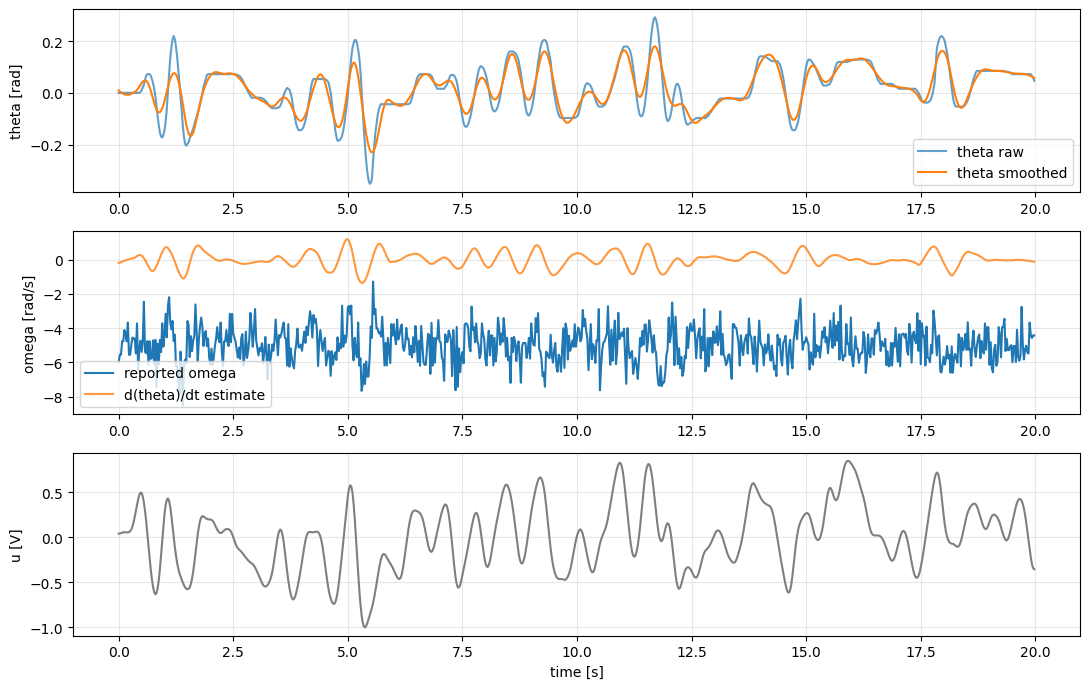

In [41]:
theta_unwrapped = np.unwrap(theta)

# Smooth before differentiating. Window must be odd and smaller than the data length.
window = min(31, len(theta_unwrapped) - (1 - len(theta_unwrapped) % 2))
if window < 7:
    raise ValueError('Not enough samples for calibration')
if window % 2 == 0:
    window -= 1

theta_smooth = signal.savgol_filter(theta_unwrapped, window_length=window, polyorder=3)
omega_from_theta = np.gradient(theta_smooth, DT)

# Ignore edge samples where filtering/differentiation is least reliable.
trim = max(window, 20)
valid = np.zeros(len(theta), dtype=bool)
valid[trim:-trim] = True

# Also avoid nearly-stationary samples when estimating scale/sign. They are useful for bias only.
moving = valid & (np.abs(omega_from_theta) > 0.5)
if moving.sum() < 20:
    print('Warning: very few moving samples. Increase TEST_AMPLITUDE or RUN_STEPS for a better scale estimate.')

plt.figure(figsize=(11, 7))
plt.subplot(3, 1, 1)
plt.plot(t, theta, label='theta raw', alpha=0.7)
plt.plot(t, theta_smooth, label='theta smoothed', lw=1.5)
plt.ylabel('theta [rad]')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(t, omega_reported, label='reported omega')
plt.plot(t, omega_from_theta, label='d(theta)/dt estimate', alpha=0.8)
plt.ylabel('omega [rad/s]')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(t, u_applied, color='tab:gray')
plt.ylabel('u [V]')
plt.xlabel('time [s]')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Fit Bias, Scale, and Delay

We fit a correction of the form:

`omega_from_angle ≈ scale * omega_reported + offset`

If the best `scale` is negative, the reported velocity sign is likely inverted.

In [42]:
def fit_scale_offset(x, y):
    A = np.column_stack([x, np.ones_like(x)])
    scale, offset = np.linalg.lstsq(A, y, rcond=None)[0]
    pred = scale * x + offset
    rmse = float(np.sqrt(np.mean((pred - y) ** 2)))
    corr = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan
    return float(scale), float(offset), rmse, corr

# Delay convention: positive delay means reported omega is shifted later before comparison.
delay_candidates = np.arange(-8, 9)
fits = []
for delay in delay_candidates:
    if delay < 0:
        idx_rep = np.arange(-delay, len(theta))
        idx_ref = np.arange(0, len(theta) + delay)
    elif delay > 0:
        idx_rep = np.arange(0, len(theta) - delay)
        idx_ref = np.arange(delay, len(theta))
    else:
        idx_rep = np.arange(len(theta))
        idx_ref = np.arange(len(theta))

    mask = valid[idx_ref] & (np.abs(omega_from_theta[idx_ref]) > 0.5)
    idx_rep = idx_rep[mask]
    idx_ref = idx_ref[mask]
    if len(idx_ref) < 20:
        continue

    scale, offset, rmse, corr = fit_scale_offset(omega_reported[idx_rep], omega_from_theta[idx_ref])
    fits.append({
        'delay_samples': int(delay),
        'delay_seconds': float(delay * DT),
        'scale': scale,
        'offset': offset,
        'rmse': rmse,
        'corr': corr,
        'n': int(len(idx_ref)),
    })

if not fits:
    raise ValueError('Could not fit omega correction. Need more movement in the calibration data.')

best = min(fits, key=lambda row: row['rmse'])
print('Best correction:')
print(f"  omega_corrected = {best['scale']:+.4f} * omega_reported + {best['offset']:+.4f}")
print(f"  delay: {best['delay_samples']} samples ({best['delay_seconds']:+.3f}s)")
print(f"  rmse:  {best['rmse']:.4f} rad/s")
print(f"  corr:  {best['corr']:.4f}")
print(f"  n:     {best['n']}")

omega_corrected_full = best['scale'] * omega_reported + best['offset']
residual_full = omega_corrected_full - omega_from_theta
sigma_mask = valid & (np.abs(omega_from_theta) < 10.0)
if sigma_mask.sum() > 20:
    sigma_omega_estimate = float(np.std(residual_full[sigma_mask]))
    sigma_omega_robust = float(1.4826 * np.median(np.abs(residual_full[sigma_mask] - np.median(residual_full[sigma_mask]))))
    print(f"  sigma_omega estimate:        {sigma_omega_estimate:.4f} rad/s")
    print(f"  sigma_omega robust estimate: {sigma_omega_robust:.4f} rad/s")
    print(f"  sim noise starting point:    {0.5 * sigma_omega_robust:.4f} rad/s")
else:
    sigma_omega_estimate = np.nan
    sigma_omega_robust = np.nan
    print('  Not enough valid moderate-speed samples to estimate sigma_omega.')

if best['scale'] < 0:
    print('Sign check: scale is negative, so reported omega is probably sign-flipped relative to d(theta)/dt.')

stationary = valid & (np.abs(omega_from_theta) < 0.2)
if stationary.sum() > 10:
    stationary_bias = float(np.mean(omega_reported[stationary]))
    print(f'Reported omega mean while nearly stationary: {stationary_bias:+.4f} rad/s')
else:
    print('Not enough nearly-stationary samples to estimate a direct stationary bias.')

Best correction:
  omega_corrected = +0.4161 * omega_reported + +2.0836
  delay: 1 samples (+0.025s)
  rmse:  0.5708 rad/s
  corr:  0.6648
  n:     190
  sigma_omega estimate:        0.4617 rad/s
  sigma_omega robust estimate: 0.4868 rad/s
  sim noise starting point:    0.2434 rad/s
Reported omega mean while nearly stationary: -4.9837 rad/s


## 5a. Compare Full Correction vs Offset-Only

Use this cell to check whether the fitted scale is really helping. If the offset-only correction already fixes the near-zero velocity samples but performs much worse during motion, use the full scale+offset correction. If the scale fit is unstable across repeated calibrations, prefer offset-only until you collect better motion data.


Offset-only source: stationary trials
  offset-only correction: omega_corrected = omega_raw + +4.607183
  full correction:        omega_corrected = +0.416128 * omega_raw + +2.083570

Motion samples, compared to d(theta)/dt:
  full correction RMSE:        0.5722 rad/s
  offset-only correction RMSE: 1.0137 rad/s
Near-stationary samples, mean corrected omega should be near 0:
  full correction mean:        +0.0097 rad/s
  offset-only correction mean: -0.3765 rad/s

Selected correction for augmentation/deployment cells:
  omega_corrected = +0.416128 * omega_raw + +2.083570


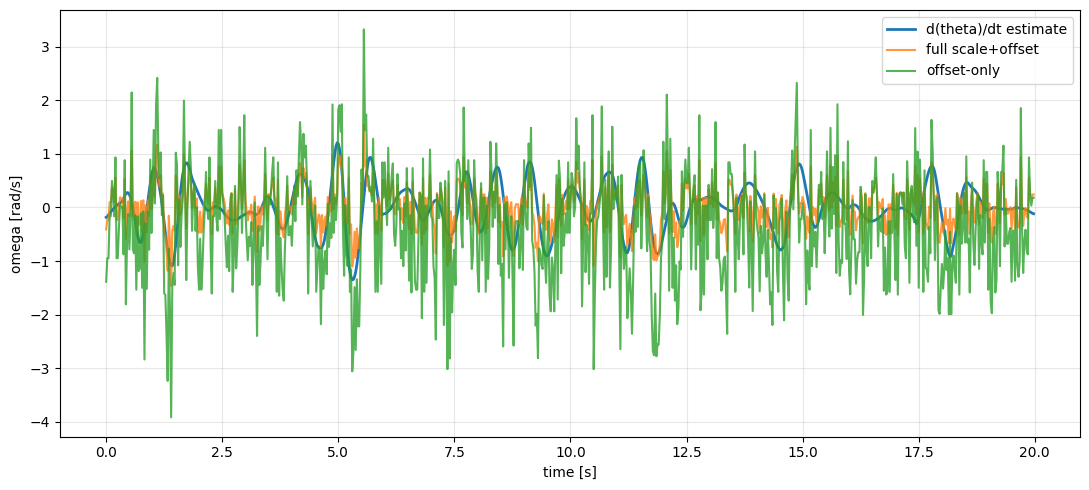

In [43]:
# Compare omega_corrected = scale * omega_raw + offset against omega_raw + offset_only.
if 'stationary_offsets' in globals() and len(stationary_offsets) > 0:
    offset_only = float(np.median(stationary_offsets))
    offset_source = 'stationary trials'
else:
    stationary_mask_for_offset = valid & (np.abs(omega_from_theta) < 0.2)
    if stationary_mask_for_offset.sum() > 10:
        offset_only = -float(np.mean(omega_reported[stationary_mask_for_offset]))
        offset_source = 'nearly-stationary samples inside driven calibration'
    else:
        offset_only = -float(np.mean(omega_reported[valid]))
        offset_source = 'all valid samples fallback'

omega_offset_only = omega_reported + offset_only
omega_full_correction = best['scale'] * omega_reported + best['offset']

fit_mask = valid & (np.abs(omega_from_theta) > 0.5)
stationary_mask = valid & (np.abs(omega_from_theta) < 0.2)

def rmse(a, b, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[mask] - b[mask]) ** 2)))

full_motion_rmse = rmse(omega_full_correction, omega_from_theta, fit_mask)
offset_motion_rmse = rmse(omega_offset_only, omega_from_theta, fit_mask)
full_stationary_mean = (
    float(np.mean(omega_full_correction[stationary_mask])) if stationary_mask.sum() else np.nan
)
offset_stationary_mean = (
    float(np.mean(omega_offset_only[stationary_mask])) if stationary_mask.sum() else np.nan
)

print(f'Offset-only source: {offset_source}')
print(f'  offset-only correction: omega_corrected = omega_raw + {offset_only:+.6f}')
print(
    f'  full correction:        '
    f'omega_corrected = {best["scale"]:+.6f} * omega_raw + {best["offset"]:+.6f}'
)
print('')
print('Motion samples, compared to d(theta)/dt:')
print(f'  full correction RMSE:        {full_motion_rmse:.4f} rad/s')
print(f'  offset-only correction RMSE: {offset_motion_rmse:.4f} rad/s')
print('Near-stationary samples, mean corrected omega should be near 0:')
print(f'  full correction mean:        {full_stationary_mean:+.4f} rad/s')
print(f'  offset-only correction mean: {offset_stationary_mean:+.4f} rad/s')

USE_OFFSET_ONLY_CORRECTION = False
if USE_OFFSET_ONLY_CORRECTION:
    SELECTED_OMEGA_SCALE = 1.0
    SELECTED_OMEGA_OFFSET = offset_only
else:
    SELECTED_OMEGA_SCALE = float(best['scale'])
    SELECTED_OMEGA_OFFSET = float(best['offset'])

print('')
print('Selected correction for augmentation/deployment cells:')
print(f'  omega_corrected = {SELECTED_OMEGA_SCALE:+.6f} * omega_raw + {SELECTED_OMEGA_OFFSET:+.6f}')

plt.figure(figsize=(11, 5))
plt.plot(t, omega_from_theta, label='d(theta)/dt estimate', lw=2)
plt.plot(t, omega_full_correction, label='full scale+offset', alpha=0.8)
plt.plot(t, omega_offset_only, label='offset-only', alpha=0.8)
plt.ylabel('omega [rad/s]')
plt.xlabel('time [s]')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Visualize the Correction

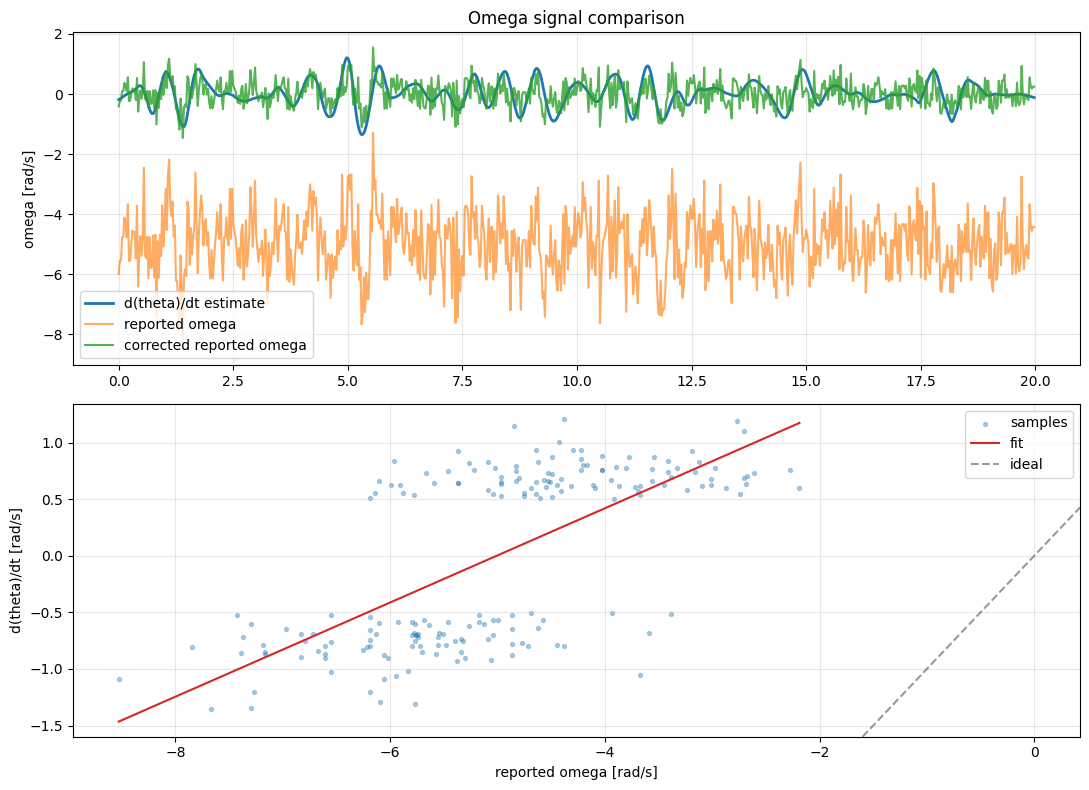

Use this before passing observations to the policy:
omega_corrected = +0.416128 * omega_measured + +2.083570
Best-fit delay was 1 samples. Treat this as diagnostic; do not blindly add delay compensation without testing.


In [44]:
scale = best['scale']
offset = best['offset']
delay = best['delay_samples']
omega_corrected = scale * omega_reported + offset

plt.figure(figsize=(11, 8))

plt.subplot(2, 1, 1)
plt.plot(t, omega_from_theta, label='d(theta)/dt estimate', lw=2)
plt.plot(t, omega_reported, label='reported omega', alpha=0.65)
plt.plot(t, omega_corrected, label='corrected reported omega', alpha=0.8)
plt.title('Omega signal comparison')
plt.ylabel('omega [rad/s]')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.scatter(omega_reported[moving], omega_from_theta[moving], s=8, alpha=0.35, label='samples')
xline = np.linspace(np.min(omega_reported[moving]), np.max(omega_reported[moving]), 100) if moving.any() else np.linspace(-1, 1, 100)
plt.plot(xline, scale * xline + offset, color='tab:red', label='fit')
plt.axline((0, 0), slope=1, color='k', ls='--', alpha=0.4, label='ideal')
plt.xlabel('reported omega [rad/s]')
plt.ylabel('d(theta)/dt [rad/s]')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Use this before passing observations to the policy:')
print(f'omega_corrected = {scale:+.6f} * omega_measured + {offset:+.6f}')
if delay != 0:
    print(f'Best-fit delay was {delay} samples. Treat this as diagnostic; do not blindly add delay compensation without testing.')

## 7. How to Apply the Correction

If the fit looks trustworthy, apply the correction in your real-policy wrapper before calling `model.predict`:

```python
obs_corrected = obs.copy()
obs_corrected[2] = scale * obs[2] + offset
action, _ = model.predict(obs_corrected, deterministic=True)
```

For the non-sincos hardware environment, the raw observation is `[theta, omega]`, so the omega entry is `obs[1]` instead of `obs[2]`.

## Recommended Order Before Real Augmentation

Before fine-tuning on the physical setup, first test the provided `.zip` policy with omega correction only. Use the deployment section at the end of this notebook with `RUN_REAL_DEPLOYMENT = True` and your chosen `DEPLOY_MODEL_ZIP`.

Recommended workflow:

1. Run the omega calibration and choose `OMEGA_SCALE`, `OMEGA_OFFSET`.
2. Deploy/test the sim-trained policy with corrected omega and no learning.
3. Compare candidate policies, for example no-noise vs sigma-noise trained policies.
4. Only run real augmentation if corrected deployment is still not good enough.

This avoids using real-training episodes to compensate for a sensor calibration problem that may already be fixed by the corrected observation.

## 8. Real-Setup Policy Augmentation with Corrected Omega

This section fine-tunes an existing A2C `.zip` policy on the physical setup, using the omega correction found above. It mirrors the real-training cell in `python-disk-test.ipynb`, but returns corrected observations to the policy and computes the training reward with corrected omega.

Set `BASE_MODEL_ZIP` to the model provided by your group/TA. Keep `RUN_REAL_AUGMENTATION = False` until the setup is connected and you are ready to train.

In [57]:
import importlib
import usb.core
import gymnasium as gym
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

import a2c_unbalanced_disk_train as disk_rl
importlib.reload(disk_rl)

RUN_REAL_AUGMENTATION = True

# Provide the starting policy zip here. Relative paths are resolved from this notebook folder.
BASE_MODEL_ZIP = Path('simple_a2c_zip_models/a2c_unbalanced_disk_noise_omega_01.zip')
RUN_NAME = 'omega_corrected_real_augmented'

# Use the correction selected in the comparison cell when available.
# If you want offset-only, set USE_OFFSET_ONLY_CORRECTION = True in section 5a and re-run from there.
OMEGA_SCALE = float(SELECTED_OMEGA_SCALE) if 'SELECTED_OMEGA_SCALE' in globals() else (float(best['scale']) if 'best' in globals() else 1.0)
OMEGA_OFFSET = float(SELECTED_OMEGA_OFFSET) if 'SELECTED_OMEGA_OFFSET' in globals() else (float(best['offset']) if 'best' in globals() else 0.0)

REAL_EPISODE_STEPS = 300
REAL_TRAIN_EPISODES = 250
REAL_TRAIN_STEPS = REAL_TRAIN_EPISODES * REAL_EPISODE_STEPS
CHECKPOINT_EVERY_EPISODES = 25
REAL_LEARNING_RATE = 1e-5
MAX_ABS_OMEGA_CORRECTED = 35.0
USB_RESET_RETRIES = 3
USB_RETRY_SLEEP = 0.25
USB_TIMEOUT_PENALTY = -5.0

base_model_candidates = [
    BASE_MODEL_ZIP,
    Path.cwd() / BASE_MODEL_ZIP,
    Path.cwd() / 'gym-unbalanced-disk-master' / 'gym_unbalanced_disk' / 'examples-connect-to-exp' / BASE_MODEL_ZIP,
    Path.cwd() / 'ML-for-control-systems-Pendulum' / 'gym-unbalanced-disk-master' / 'gym_unbalanced_disk' / 'examples-connect-to-exp' / BASE_MODEL_ZIP,
]
base_model_path = next((path for path in base_model_candidates if path.exists()), base_model_candidates[0])

run_dir = Path('real_setup_checkpoints_omega_corrected') / RUN_NAME
run_dir.mkdir(parents=True, exist_ok=True)
augmented_model_path = run_dir / f'{base_model_path.stem}_{RUN_NAME}.zip'

print(f'Base model:         {base_model_path}')
print(f'Run dir:            {run_dir}')
print(f'Augmented model:    {augmented_model_path}')
print(f'Omega correction:   omega_corrected = {OMEGA_SCALE:+.6f} * omega_raw + {OMEGA_OFFSET:+.6f}')
print(f'Train episodes:     {REAL_TRAIN_EPISODES}')
print(f'Learning rate:      {REAL_LEARNING_RATE}')

Base model:         simple_a2c_zip_models\a2c_unbalanced_disk_noise_omega_01.zip
Run dir:            real_setup_checkpoints_omega_corrected\omega_corrected_real_augmented
Augmented model:    real_setup_checkpoints_omega_corrected\omega_corrected_real_augmented\a2c_unbalanced_disk_noise_omega_01_omega_corrected_real_augmented.zip
Omega correction:   omega_corrected = +0.416128 * omega_raw + +2.083570
Train episodes:     250
Learning rate:      1e-05


In [58]:
def correct_sincos_obs(obs, scale=OMEGA_SCALE, offset=OMEGA_OFFSET):
    obs = np.asarray(obs, dtype=np.float32).copy()
    obs[2] = scale * obs[2] + offset
    return obs


class CorrectedOmegaRealDiskFineTuneEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, dt=DT, umax=UMAX, max_episode_steps=300, max_abs_omega=35.0):
        super().__init__()
        self.dt = dt
        self.umax = umax
        self.max_episode_steps = max_episode_steps
        self.max_abs_omega = max_abs_omega
        self.steps = 0
        self.env = self._make_hardware_env()
        self.observation_space = self.env.observation_space
        self.action_space = gym.spaces.Box(
            low=np.array([-umax], dtype=np.float32),
            high=np.array([umax], dtype=np.float32),
            dtype=np.float32,
        )
        self.last_obs = np.array([0.0, 1.0, 0.0], dtype=np.float32)

    def _make_hardware_env(self):
        return gym_unbalanced_disk.UnbalancedDisk_exp_sincos(dt=self.dt, umax=self.umax)

    def _safe_zero(self):
        try:
            self.env.step(0.0)
        except usb.core.USBError as exc:
            print(f'USB error while sending zero command: {exc}')

    def _reconnect(self):
        try:
            self.env.close()
        except Exception:
            pass
        time.sleep(USB_RETRY_SLEEP)
        self.env = self._make_hardware_env()

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        self.steps = 0
        last_error = None
        for attempt in range(1, USB_RESET_RETRIES + 1):
            try:
                obs, info = self.env.reset(seed=seed)
                obs = correct_sincos_obs(obs)
                self.last_obs = obs
                return obs, info
            except usb.core.USBError as exc:
                last_error = exc
                print(f'USB reset/read error on attempt {attempt}/{USB_RESET_RETRIES}: {exc}')
                self._reconnect()
        raise last_error

    def step(self, action):
        u = float(np.asarray(action, dtype=np.float32).reshape(-1)[0])
        u = float(np.clip(u, -self.umax, self.umax))
        try:
            raw_obs, env_reward, terminated, truncated, info = self.env.step(u)
        except usb.core.USBError as exc:
            self.steps += 1
            self._safe_zero()
            info = {
                'usb_error': str(exc),
                'u': u,
                'safety_truncated': True,
            }
            print(f'USB step/read error; ending episode and continuing training: {exc}')
            return self.last_obs, USB_TIMEOUT_PENALTY, False, True, info

        self.steps += 1
        obs = correct_sincos_obs(raw_obs)
        self.last_obs = obs

        theta = float(self.env.th)
        omega_raw = float(self.env.omega)
        omega_corrected = float(obs[2])
        reward = disk_rl.external_balance_reward(theta, omega_corrected, u, self.umax)
        safety_truncated = abs(omega_corrected) > self.max_abs_omega
        time_truncated = self.steps >= self.max_episode_steps

        info = {
            **info,
            'theta': theta,
            'omega_raw': omega_raw,
            'omega': omega_corrected,
            'omega_corrected': omega_corrected,
            'env_reward': float(env_reward),
            'train_reward': float(reward),
            'u': u,
            'safety_truncated': bool(safety_truncated),
        }
        return (
            obs,
            float(reward),
            bool(terminated),
            bool(truncated or time_truncated or safety_truncated),
            info,
        )

    def close(self):
        try:
            self._safe_zero()
        finally:
            self.env.close()


def make_corrected_real_env():
    return Monitor(
        CorrectedOmegaRealDiskFineTuneEnv(
            dt=DT,
            umax=UMAX,
            max_episode_steps=REAL_EPISODE_STEPS,
            max_abs_omega=MAX_ABS_OMEGA_CORRECTED,
        )
    )

In [59]:
class EpisodeModelCheckpoint(BaseCallback):
    def __init__(self, save_path, every_episodes=25, print_every_episodes=1):
        super().__init__()
        self.save_path = Path(save_path)
        self.every_episodes = every_episodes
        self.print_every_episodes = print_every_episodes
        self.episodes = 0
        self.recent_rewards = []

    def _on_step(self):
        infos = self.locals.get('infos', [])
        dones = self.locals.get('dones', [])
        for done, info in zip(dones, infos):
            if done:
                self.episodes += 1
                episode = info.get('episode', {})
                ep_reward = float(episode.get('r', np.nan))
                ep_length = int(episode.get('l', 0))
                if np.isfinite(ep_reward):
                    self.recent_rewards.append(ep_reward)
                    self.recent_rewards = self.recent_rewards[-10:]
                mean10 = float(np.nanmean(self.recent_rewards)) if self.recent_rewards else np.nan
                usb_error = info.get('usb_error')
                safety = info.get('safety_truncated', False)

                if self.episodes % self.print_every_episodes == 0:
                    print(
                        f'episode {self.episodes}/{REAL_TRAIN_EPISODES} | '
                        f'reward={ep_reward:.2f} | mean10={mean10:.2f} | '
                        f'len={ep_length} | steps={self.num_timesteps} | '
                        f'safety={safety} | usb_error={bool(usb_error)}'
                    )

                if self.episodes % self.every_episodes == 0:
                    checkpoint_path = self.save_path / f'model_{self.episodes:03d}'
                    self.model.save(checkpoint_path)
                    print(f'Saved model checkpoint: {checkpoint_path}.zip')
        return True


if RUN_REAL_AUGMENTATION:
    if not base_model_path.exists():
        raise FileNotFoundError(f'Could not find BASE_MODEL_ZIP. Checked: {base_model_candidates}')

    train_env = DummyVecEnv([make_corrected_real_env])
    model = A2C.load(
        base_model_path,
        env=train_env,
        device='cpu',
        custom_objects={
            'learning_rate': REAL_LEARNING_RATE,
            'lr_schedule': lambda _: REAL_LEARNING_RATE,
        },
    )

    checkpoint_callback = EpisodeModelCheckpoint(
        save_path=run_dir,
        every_episodes=CHECKPOINT_EVERY_EPISODES,
        print_every_episodes=1,
    )

    try:
        model.learn(
            total_timesteps=REAL_TRAIN_STEPS,
            reset_num_timesteps=False,
            progress_bar=False,
            callback=checkpoint_callback,
        )
        model.save(augmented_model_path)
        print(f'Saved omega-corrected real augmented model: {augmented_model_path}')
    finally:
        train_env.close()
else:
    print('Real augmentation skipped. Set RUN_REAL_AUGMENTATION = True when connected to the lab setup.')

USB read error
episode 1/250 | reward=20.41 | mean10=20.41 | len=300 | steps=300300 | safety=False | usb_error=False
USB step/read error; ending episode and continuing training: [Errno None] b'libusb0-dll:err [_usb_reap_async] timeout error\n'
USB read error
USB read error
episode 2/250 | reward=5.76 | mean10=13.09 | len=141 | steps=300441 | safety=True | usb_error=True
USB read error
USB read error
USB read error
USB read error
USB read error
USB read error
episode 3/250 | reward=55.03 | mean10=27.07 | len=300 | steps=300741 | safety=False | usb_error=False
USB step/read error; ending episode and continuing training: [Errno None] b'libusb0-dll:err [_usb_reap_async] timeout error\n'
episode 4/250 | reward=38.26 | mean10=29.87 | len=245 | steps=300986 | safety=True | usb_error=True
USB read error
episode 5/250 | reward=9.27 | mean10=25.75 | len=300 | steps=301286 | safety=False | usb_error=False
USB read error
USB read error
episode 6/250 | reward=15.66 | mean10=24.07 | len=300 | steps=

## 9. Deploy a Policy on the Real Setup with Corrected Omega

Use this after real augmentation, or to test any `.zip` policy on the physical setup. The saved model does not contain the omega correction, so this deployment cell applies the correction to `obs[2]` before every `model.predict(...)` call.

In [64]:
RUN_REAL_DEPLOYMENT = True

# By default, deploy the augmented model path from the training section.
# You can replace this with any A2C .zip path you want to test.
DEPLOY_MODEL_ZIP = "real_setup_checkpoints_omega_corrected/omega_corrected_real_augmented/model_250.zip"#augmented_model_path if 'augmented_model_path' in globals() else BASE_MODEL_ZIP

DEPLOY_STEPS = 1200
DEPLOY_DETERMINISTIC = True
ACTION_SIGN = 1.0  # use -1.0 only if the hardware polarity is opposite
PRINT_FIRST_STEPS = 20
SAVE_DEPLOYMENT_LOG = True

deploy_model_candidates = [
    Path(DEPLOY_MODEL_ZIP),
    Path.cwd() / Path(DEPLOY_MODEL_ZIP),
]
deploy_model_path = next((path for path in deploy_model_candidates if path.exists()), deploy_model_candidates[0])

print(f'Deploy model:       {deploy_model_path}')
print(f'Omega correction:   omega_corrected = {OMEGA_SCALE:+.6f} * omega_raw + {OMEGA_OFFSET:+.6f}')
print(f'Deploy steps:       {DEPLOY_STEPS}')
print(f'Deterministic:      {DEPLOY_DETERMINISTIC}')
print(f'Action sign:        {ACTION_SIGN:+.1f}')

Deploy model:       real_setup_checkpoints_omega_corrected\omega_corrected_real_augmented\model_250.zip
Omega correction:   omega_corrected = +0.416128 * omega_raw + +2.083570
Deploy steps:       1200
Deterministic:      True
Action sign:        +1.0


In [ ]:
if RUN_REAL_DEPLOYMENT:
    if not deploy_model_path.exists():
        raise FileNotFoundError(f'Could not find DEPLOY_MODEL_ZIP. Checked: {deploy_model_candidates}')

    deploy_model = A2C.load(deploy_model_path, device='cpu')
    deploy_env = gym_unbalanced_disk.UnbalancedDisk_exp_sincos(dt=DT, umax=UMAX)

    obs_raw_list = []
    obs_corrected_list = []
    u_model_list = []
    u_applied_list = []
    theta_list = []
    omega_raw_list = []
    omega_corrected_list = []
    wall_time_list = []

    try:
        obs_raw, info = deploy_env.reset()
        t0 = time.perf_counter()
        for k in range(DEPLOY_STEPS):
            obs_corrected = correct_sincos_obs(obs_raw)
            action, _ = deploy_model.predict(obs_corrected, deterministic=DEPLOY_DETERMINISTIC)
            u_model = float(np.asarray(action).reshape(-1)[0])
            u_applied = float(np.clip(ACTION_SIGN * u_model, -UMAX, UMAX))

            obs_raw_list.append(np.asarray(obs_raw, dtype=np.float32).copy())
            obs_corrected_list.append(obs_corrected.copy())
            u_model_list.append(u_model)
            u_applied_list.append(u_applied)
            theta_list.append(float(deploy_env.th))
            omega_raw_list.append(float(obs_raw[2]))
            omega_corrected_list.append(float(obs_corrected[2]))
            wall_time_list.append(time.perf_counter() - t0)

            if k < PRINT_FIRST_STEPS:
                print(
                    f'k={k:03d} raw={np.round(obs_raw, 3)} corrected={np.round(obs_corrected, 3)} '
                    f'model_u={u_model:+.3f} applied_u={u_applied:+.3f}'
                )

            obs_raw, reward, terminal, truncated, info = deploy_env.step(u_applied)
            if terminal or truncated:
                break
    finally:
        try:
            deploy_env.step(0.0)
        finally:
            deploy_env.close()

    obs_raw_arr = np.asarray(obs_raw_list)
    obs_corrected_arr = np.asarray(obs_corrected_list)
    u_model_arr = np.asarray(u_model_list)
    u_applied_arr = np.asarray(u_applied_list)
    theta_arr = np.asarray(theta_list)
    omega_raw_arr = np.asarray(omega_raw_list)
    omega_corrected_arr = np.asarray(omega_corrected_list)
    wall_time_arr = np.asarray(wall_time_list)
    t_deploy = np.arange(len(u_applied_arr)) * DT

    print(f'Ran deployment for {len(u_applied_arr)} steps ({len(u_applied_arr) * DT:.1f}s)')
    if len(u_applied_arr):
        print(f'max |model_u| = {np.max(np.abs(u_model_arr)):.2f} V')
        print(f'max |applied_u| = {np.max(np.abs(u_applied_arr)):.2f} V')
        print(f'omega raw range = {omega_raw_arr.min():+.2f} to {omega_raw_arr.max():+.2f} rad/s')
        print(f'omega corrected range = {omega_corrected_arr.min():+.2f} to {omega_corrected_arr.max():+.2f} rad/s')

    if SAVE_DEPLOYMENT_LOG:
        stamp = time.strftime('%Y%m%d_%H%M%S')
        log_path = run_dir / f'deployment_{deploy_model_path.stem}_{stamp}.npz'
        np.savez(
            log_path,
            t=t_deploy,
            wall_time=wall_time_arr,
            obs_raw=obs_raw_arr,
            obs_corrected=obs_corrected_arr,
            theta=theta_arr,
            omega_raw=omega_raw_arr,
            omega_corrected=omega_corrected_arr,
            u_model=u_model_arr,
            u_applied=u_applied_arr,
            omega_scale=OMEGA_SCALE,
            omega_offset=OMEGA_OFFSET,
            action_sign=ACTION_SIGN,
            model_path=str(deploy_model_path),
        )
        print(f'Saved deployment log: {log_path}')

    fig, axs = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
    axs[0].plot(t_deploy, np.unwrap(theta_arr), label='theta unwrapped')
    axs[0].set_ylabel('theta [rad]')
    axs[0].legend()
    axs[1].plot(t_deploy, omega_raw_arr, label='raw omega', alpha=0.7)
    axs[1].plot(t_deploy, omega_corrected_arr, label='corrected omega', alpha=0.85)
    axs[1].set_ylabel('omega [rad/s]')
    axs[1].legend()
    axs[2].plot(t_deploy, u_model_arr, label='model')
    axs[2].plot(t_deploy, u_applied_arr, label='applied', ls='--')
    axs[2].set_ylabel('u [V]')
    axs[2].set_ylim(-UMAX - 0.2, UMAX + 0.2)
    axs[2].legend()
    axs[3].plot(t_deploy, obs_corrected_arr[:, 0], label='sin(theta)')
    axs[3].plot(t_deploy, obs_corrected_arr[:, 1], label='cos(theta)')
    axs[3].set_ylabel('obs')
    axs[3].set_xlabel('time [s]')
    axs[3].legend()
    for ax in axs:
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('Real deployment skipped. Set RUN_REAL_DEPLOYMENT = True when connected to the lab setup.')

k=000 raw=[ 0.     1.    -4.383] corrected=[0.   1.   0.26] model_u=-3.000 applied_u=-3.000
k=001 raw=[ 0.     1.    -4.331] corrected=[0.    1.    0.281] model_u=-3.000 applied_u=-3.000
k=002 raw=[-0.022  1.    -5.906] corrected=[-0.022  1.    -0.374] model_u=-3.000 applied_u=-3.000
k=003 raw=[-0.113  0.994 -6.714] corrected=[-0.113  0.994 -0.71 ] model_u=-3.000 applied_u=-3.000
k=004 raw=[-0.236  0.972 -7.938] corrected=[-0.236  0.972 -1.22 ] model_u=-3.000 applied_u=-3.000
k=005 raw=[-0.397  0.918 -8.818] corrected=[-0.397  0.918 -1.586] model_u=-3.000 applied_u=-3.000
k=006 raw=[ -0.557   0.831 -10.43 ] corrected=[-0.557  0.831 -2.257] model_u=-3.000 applied_u=-3.000
k=007 raw=[ -0.696   0.718 -11.31 ] corrected=[-0.696  0.718 -2.623] model_u=-3.000 applied_u=-3.000
k=008 raw=[-0.805  0.593 -8.598] corrected=[-0.805  0.593 -1.494] model_u=-3.000 applied_u=-3.000
k=009 raw=[-0.884  0.468 -8.158] corrected=[-0.884  0.468 -1.311] model_u=-3.000 applied_u=-3.000
k=010 raw=[-0.929  0.37